# Homework

In [17]:
import polars as pl

DATA_DIR = "data"

## 1. Data reading

In [18]:
dfs = []
for month in range(1, 13):
    df = pl.scan_parquet(f"{DATA_DIR}/{month}.parquet")
    df = df.with_columns(
        pl.col("tpep_pickup_datetime").dt.cast_time_unit("ms"),
        pl.col("tpep_dropoff_datetime").dt.cast_time_unit("ms"),
    )
    dfs.append(df)

df_2024 = pl.concat(dfs)

In [19]:
df_taxi_zones = pl.scan_csv("data/taxi_zone_lookup.csv")

In [20]:
df_final = (
    df_2024.filter(
        (pl.col("tpep_pickup_datetime") >= pl.datetime(2024, 1, 1))
        & (pl.col("tpep_pickup_datetime") <= pl.datetime(2025, 1, 1))
    ).cast({
        "VendorID": pl.UInt8,
        "passenger_count": pl.UInt8,
        "RatecodeID": pl.UInt8,
        "store_and_fwd_flag": pl.Categorical,
        "payment_type": pl.UInt8,
    })
    # 2. Data cleaning
    .with_columns(
        passenger_count=pl.col("passenger_count").fill_null(1),
        trip_time=(pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")).dt.total_minutes()
    ).filter(
        pl.col("passenger_count") > 0,
        pl.col("trip_time") > 0,
        pl.col("trip_time") < 120
    ).with_columns(
        passenger_count=pl.when(pl.col("passenger_count") > 6).then(6).otherwise(pl.col("passenger_count")),
        extra=pl.col("extra").abs(),
        mta_tax=pl.col("mta_tax").abs(),
        tip_amount=pl.col("tip_amount").abs(),
        tolls_amount=pl.col("tolls_amount").abs(),
        improvement_surcharge=pl.col("improvement_surcharge").abs(),
        total_amount=pl.col("total_amount").abs(),
        congestion_surcharge=pl.col("congestion_surcharge").abs(),
        Airport_fee=pl.col("Airport_fee").abs(),
    ).remove(
        (pl.col("extra") > 1000)
        | (pl.col("mta_tax") > 1000)
        | (pl.col("tip_amount") > 1000)
        | (pl.col("tolls_amount") > 1000)
        | (pl.col("improvement_surcharge") > 1000)
        | (pl.col("total_amount") > 1000)
        | (pl.col("congestion_surcharge") > 1000)
        | (pl.col("Airport_fee") > 1000)
        | (~pl.col("VendorID").is_in([1, 2, 6, 7]))
        | (~pl.col("RatecodeID").is_in([1, 2, 3, 4, 5, 6, 99]))
    )
    # 3. Data transformation
    .join(
        df_taxi_zones.rename({"Borough": "PUBorough", "Zone": "PUZone"}), left_on="PULocationID", right_on="LocationID"
    ).join(
        df_taxi_zones.rename({"Borough": "DOBorough", "Zone": "DOZone"}), left_on="DOLocationID", right_on="LocationID"
    ).drop(
        "PULocationID", "DOLocationID"
    ).with_columns(
        payment_type=pl.when(pl.col("payment_type").is_in([1, 2])).then(pl.col("payment_type")).otherwise(3),
        is_airport_ride=pl.when(pl.col("Airport_fee") > 0).then(True).otherwise(False),
        is_rush_hour=pl.when(
            (
                (
                    (pl.col("tpep_pickup_datetime").dt.time() >= pl.time(6, 30))
                    & (pl.col("tpep_pickup_datetime").dt.time() <= pl.time(9, 30))
                )
                |
                (
                    (pl.col("tpep_pickup_datetime").dt.time() >= pl.time(15, 30))
                    & (pl.col("tpep_pickup_datetime").dt.time() <= pl.time(20, 0))
                )
            )
            &
            (pl.col("tpep_pickup_datetime").dt.weekday() <= 4)
        ).then(True).otherwise(False),
    )
    # 4. Feature extraction
    .collect()
    .to_dummies(columns=["payment_type", "PUBorough", "DOBorough"])
    .lazy()
    .group_by(pl.col("tpep_pickup_datetime").dt.date().alias("date"))
    .agg(
        total_trips=pl.count(),
        airport_rides=pl.sum("is_airport_ride"),
        rush_hour_rides=pl.sum("is_rush_hour"),
        avg_fare_amount=pl.mean("fare_amount"),
        median_distance=pl.median("trip_distance"),
        sum_of_amounts=pl.sum("total_amount"),
        total_paid_by_cash=pl.when(pl.col("payment_type_1") == 1).then(pl.col("total_amount")).otherwise(0).sum(),
        total_paid_by_card=pl.when(pl.col("payment_type_2") == 1).then(pl.col("total_amount")).otherwise(0).sum(),
        total_paid_by_other=pl.when(pl.col("payment_type_3") == 1).then(pl.col("total_amount")).otherwise(0).sum(),
        total_congestion_surcharge=pl.sum("congestion_surcharge"),
        total_number_of_passengers=pl.sum("passenger_count"),
    ).with_columns(
        quarter=pl.col("date").dt.quarter().cast(pl.UInt8),
        month=pl.col("date").dt.month().cast(pl.UInt8),
        day_of_month=pl.col("date").dt.day().cast(pl.UInt8),
        day_of_week=pl.col("date").dt.weekday().cast(pl.UInt8),
        is_weekend=pl.when(pl.col("date").dt.weekday() >= 5).then(True).otherwise(False)
    ).sort("date")
    .collect()
)

/tmp/ipykernel_48305/3555943471.py:74: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  total_trips=pl.count(),


In [21]:
df_final.shape

(366, 17)

In [22]:
df_final.head()

date,total_trips,airport_rides,rush_hour_rides,avg_fare_amount,median_distance,sum_of_amounts,total_paid_by_cash,total_paid_by_card,total_paid_by_other,total_congestion_surcharge,total_number_of_passengers,quarter,month,day_of_month,day_of_week,is_weekend
date,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,i64,u8,u8,u8,u8,bool
2024-01-01,78747,8159,20855,21.645179,2.1,2.4225e6,1.7023e6,375693.09,344475.77,154545.0,117423,1,1,1,1,false
2024-01-02,73610,9629,31587,20.807005,1.87,2.2650e6,1.7690e6,391219.11,104769.82,159397.5,104465,1,1,2,2,false
2024-01-03,80441,8983,33861,19.545626,1.79,2.3463e6,1.8390e6,407376.76,99936.7,176757.5,111302,1,1,3,3,false
2024-01-04,100604,8106,44464,18.322771,1.78,2.7884e6,2.2275e6,436565.15,124390.81,225275.0,136799,1,1,4,4,false
2024-01-05,100818,7312,0,17.734178,1.73,2.7153e6,2.1699e6,411157.39,134195.35,226075.0,138605,1,1,5,5,true


In [23]:
df_final.describe()

statistic,date,total_trips,airport_rides,rush_hour_rides,avg_fare_amount,median_distance,sum_of_amounts,total_paid_by_cash,total_paid_by_card,total_paid_by_other,total_congestion_surcharge,total_number_of_passengers,quarter,month,day_of_month,day_of_week,is_weekend
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""366""",366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0,366.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2024-07-01 12:00:00""",109938.13388,8784.439891,26405.620219,19.156487,1.789986,3.1317e6,2.4256e6,363342.468251,342780.681749,228526.071776,144199.535519,2.505464,6.513661,15.756831,3.986339,0.42623
"""std""",null,18598.749826,1680.543904,23671.174083,1.007542,0.1209,539926.44939,427254.345606,35522.6529,144275.155427,37703.5961,22257.890698,1.119551,3.455958,8.823592,2.006108,null
"""min""","""2024-01-01""",53517.0,3239.0,0.0,16.119414,1.53,1.4721e6,976637.58,235548.82,88800.77,106782.5,79732.0,1.0,1.0,1.0,1.0,0.0
"""25%""","""2024-04-01""",96684.0,7691.0,0.0,18.494234,1.7,2.7183e6,2.1379e6,343703.81,233111.62,201608.5,128286.0,2.0,4.0,8.0,2.0,null
"""50%""","""2024-07-02""",109627.0,8813.0,36845.0,19.166245,1.77,3.1284e6,2.4296e6,367104.59,323122.76,231390.0,144636.0,3.0,7.0,16.0,4.0,null
"""75%""","""2024-10-01""",125134.0,9929.0,48095.0,19.822493,1.85,3.5169e6,2.7037e6,390609.99,445706.57,255372.5,159600.0,4.0,10.0,23.0,6.0,null
"""max""","""2024-12-31""",156567.0,14608.0,63490.0,22.57645,2.34,4.8163e6,3.8697e6,438727.14,738140.09,327985.0,216696.0,4.0,12.0,31.0,7.0,1.0


In [25]:
df_final.schema

Schema([('date', Date),
        ('total_trips', UInt32),
        ('airport_rides', UInt32),
        ('rush_hour_rides', UInt32),
        ('avg_fare_amount', Float64),
        ('median_distance', Float64),
        ('sum_of_amounts', Float64),
        ('total_paid_by_cash', Float64),
        ('total_paid_by_card', Float64),
        ('total_paid_by_other', Float64),
        ('total_congestion_surcharge', Float64),
        ('total_number_of_passengers', Int64),
        ('quarter', UInt8),
        ('month', UInt8),
        ('day_of_month', UInt8),
        ('day_of_week', UInt8),
        ('is_weekend', Boolean)])

<Axes: title={'center': 'Total Trips per Day in 2024'}, xlabel='Date', ylabel='Total Trips'>

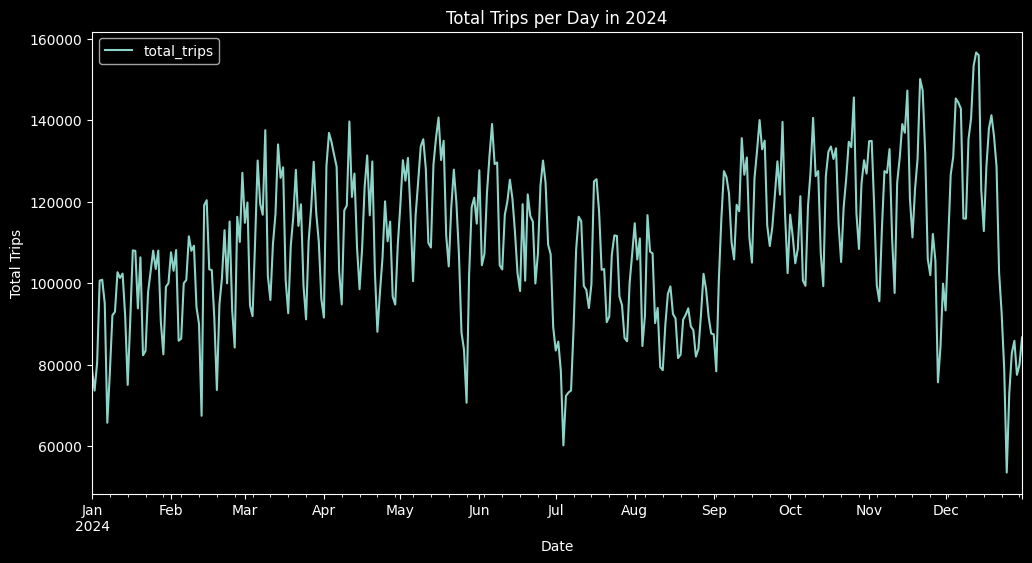

In [26]:
df_final.to_pandas().plot(
    x="date",
    y="total_trips",
    kind="line",
    title="Total Trips per Day in 2024",
    xlabel="Date",
    ylabel="Total Trips",
    figsize=(12, 6)
)

In [27]:
df_final.write_parquet("dataset.parquet")